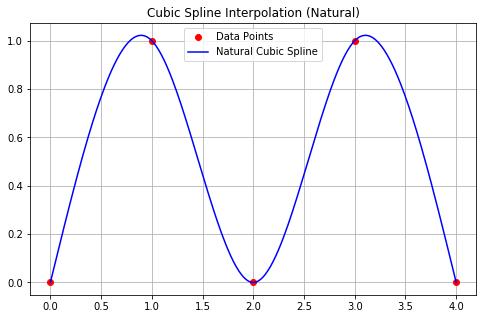

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Step 1: Natural Cubic Spline Construction
# ---------------------------------------------------------

def natural_cubic_spline(x, y):
    n = len(x)
    h = np.diff(x)

    # Step 3: Build the tridiagonal system
    A = np.zeros(n)
    B = np.zeros(n)
    C = np.zeros(n)
    D = np.zeros(n)

    # Natural boundary conditions
    B[0] = 1
    B[-1] = 1
    D[0] = 0
    D[-1] = 0

    # Fill interior rows
    for i in range(1, n - 1):
        A[i] = h[i - 1]
        B[i] = 2 * (h[i - 1] + h[i])
        C[i] = h[i]
        D[i] = 6 * ((y[i + 1] - y[i]) / h[i] - (y[i] - y[i - 1]) / h[i - 1])

    # Solve using Thomas Algorithm
    M = thomas_algorithm(A, B, C, D)
    return M


# ---------------------------------------------------------
# Thomas Algorithm for Tridiagonal Systems
# ---------------------------------------------------------

def thomas_algorithm(A, B, C, D):
    n = len(B)
    # Forward elimination
    for i in range(1, n):
        w = A[i] / B[i - 1]
        B[i] = B[i] - w * C[i - 1]
        D[i] = D[i] - w * D[i - 1]

    # Back substitution
    M = np.zeros(n)
    M[-1] = D[-1] / B[-1]

    for i in range(n - 2, -1, -1):
        M[i] = (D[i] - C[i] * M[i + 1]) / B[i]

    return M


# ---------------------------------------------------------
# Step 4: Evaluate the Spline at New Points
# ---------------------------------------------------------

def evaluate_spline(x, y, M, x_eval):
    x_eval = np.array(x_eval)
    y_eval = np.zeros_like(x_eval)

    for j, xe in enumerate(x_eval):
        # Find interval i such that x[i] <= xe <= x[i+1]
        i = np.searchsorted(x, xe) - 1
        if i < 0:
            i = 0
        if i >= len(x) - 1:
            i = len(x) - 2

        h = x[i+1] - x[i]

        # Cubic spline formula
        A = (x[i+1] - xe) / h
        B = (xe - x[i]) / h

        y_eval[j] = (
            A * y[i] + B * y[i+1]
            + ((A**3 - A) * M[i] * h**2) / 6
            + ((B**3 - B) * M[i+1] * h**2) / 6
        )

    return y_eval


# ---------------------------------------------------------
# Example Usage
# ---------------------------------------------------------

# Sample data
x = np.array([0, 1, 2, 3, 4])
y = np.array([0, 1, 0, 1, 0])

# Build spline
M = natural_cubic_spline(x, y)

# Evaluate spline at many points
x_new = np.linspace(min(x), max(x), 300)
y_new = evaluate_spline(x, y, M, x_new)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(x, y, 'ro', label="Data Points")
plt.plot(x_new, y_new, 'b-', label="Natural Cubic Spline")
plt.title("Cubic Spline Interpolation (Natural)")
plt.legend()
plt.grid(True)
plt.show()